In [26]:
import random
from typing import Literal
from pprint import pprint

from tqdm.notebook import trange, tqdm
import numpy as np
from torchvision.datasets import CIFAR10, FashionMNIST
from torchvision.transforms.v2 import (
    GaussianNoise, Compose, ToTensor, GaussianBlur, RandomRotation, RandomHorizontalFlip, RandomVerticalFlip, RandomCrop, RandomAffine, Pad, Lambda
)
from torch.utils.data import DataLoader, ConcatDataset, Dataset, random_split, WeightedRandomSampler, Subset
from torch import nn
import torch
from matplotlib import pyplot as plt

data_dir = '~/DataScience/datasets/'

## Solution 2 -- DONE

In [52]:
def salt_and_pepper_noise(image: torch.Tensor) -> torch.Tensor:
    p = 0.05    # noise probability
    mask = torch.randn(image.shape)
    image[mask < p * 0.5] = 1         # salt
    image[1-mask < (1-p) * 0.5] = 0   # pepper
    return image

all_transforms = {
    'original': [nn.Identity()],
    'gaussian_noise': [GaussianNoise(0, 0.05, clip=True)],
    'salt_and_pepper_noise': [Lambda(salt_and_pepper_noise)],
    'rotate30': [RandomRotation(degrees=30)],
    'horizontal_flip': [RandomHorizontalFlip(p=1.0)],
    'vertical_flip': [RandomVerticalFlip(p=1.0)],
    'translate': [RandomAffine(degrees=0, translate=(0.2, 0.15))],
    'gaussian_blur': [GaussianBlur(kernel_size=3, sigma=1.5)],
    'crop': [Pad(4), RandomCrop(32)],
}

transformed_datasets = [CIFAR10(data_dir, transform=Compose([ToTensor()] + t)) for t in all_transforms.values()]
augmented_dataloader = DataLoader(ConcatDataset(transformed_datasets))

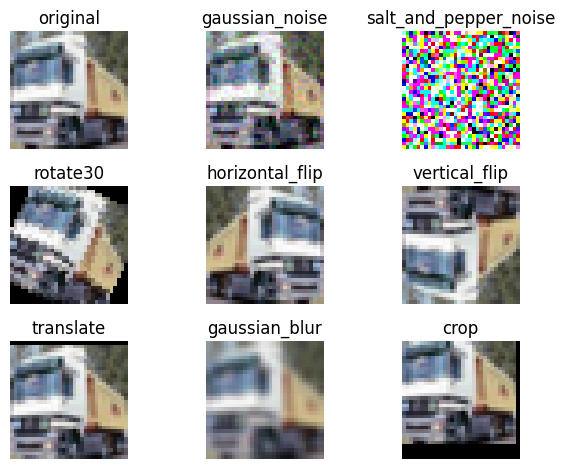

In [ ]:
names = list(all_transforms.keys())
image_index = 1
dpi = 80
fig, axes = plt.subplots(3, 3)    # CIFAR images have shape (32,32)
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        i = 3 * row + col
        image, _label = transformed_datasets[i][image_index]
        ax.imshow(image.permute(1,2,0))     # convert (C,H,W) (torch tensor format) -> (H,W,C) (matplotlib format) where H,W,C are image height,width,channels
        ax.set_title(names[i])
        ax.set_axis_off()
fig.tight_layout()

## Solution 3 -- DONE

In [32]:
loss_fn = nn.CrossEntropyLoss()
batch_size = 64
epochs = 5

In [33]:
train_ds = FashionMNIST(data_dir, download=True, train=True, transform=ToTensor())
valid_ds = FashionMNIST(data_dir, download=True, train=False, transform=ToTensor())
valid_loader = DataLoader(valid_ds, batch_size=batch_size)

/home/sohangchopra/DataScience/iit-madras-web-mtech-ai/.venv/lib64/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [34]:
generator = torch.Generator().manual_seed(42)
subsets = [Subset(train_ds, indices=torch.randint(len(train_ds), size=(38_400,), generator=generator)) for _ in range(3)]

In [37]:
def train(model, train_loader) -> None:
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(epochs):
        print('Epoch', epoch)
        for images, labels in tqdm(train_loader):
            optimizer.zero_grad()
            output_logits = model(torch.flatten(images, start_dim=1))
            loss = loss_fn(output_logits, labels)
            loss.backward()       # gradient calculation
            optimizer.step()      # update weights

def evaluate(model, output_mode: Literal['soft', 'hard']) -> float:
    """@param output_mode: 'soft' -> model outputs logits, 'hard' -> model directly outputs labels."""
    correct_predictions = 0
    with torch.no_grad():
        for images, labels in tqdm(valid_loader):
            outputs = model(torch.flatten(images, start_dim=1))
            if output_mode == 'soft':     # get output label indices (i.e. where output logits are maximum)
                outputs = torch.argmax(outputs, dim=1)
            correct_predictions += (outputs == labels).sum()
    accuracy = correct_predictions / len(valid_ds)
    return accuracy

In [38]:
models = []
for i, subset in enumerate(subsets):
    print('Subset', i)
    model = nn.Sequential(
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10),
        # Softmax NOT added, becuase CrossEntropy loss already internally applies it
    )
    train_loader = DataLoader(subset, batch_size=batch_size)
    train(model, train_loader)
    print('Evaluating trained model...')
    accuracy = evaluate(model, output_mode='soft')
    print('Accuracy:', accuracy)
    models.append(model)
    

Subset 0
Epoch 0


  0%|          | 0/600 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/600 [00:00<?, ?it/s]

Epoch 2


...

Epoch 4


  0%|          | 0/600 [00:00<?, ?it/s]

Evaluating trained model...


  0%|          | 0/157 [00:00<?, ?it/s]

Accuracy: tensor(0.8540)


In [39]:
def ensemble_model(X: torch.Tensor) -> torch.Tensor:
    """Ensemble of the 3 bootstrap models. Majority-Choice voting, tie-breaker: random output class."""
    stacked_output_indices = torch.stack([torch.argmax(model(X), dim=1) for model in models], dim=0)  # model(X): logits, argmax(): output label indices
    
    # shuffle - if all 3 models disagree, then "winner" is random
    permutation = torch.randperm(stacked_output_indices.size(0), generator=generator)
    shuffled_outputs = stacked_output_indices[permutation]
    
    mode = torch.mode(shuffled_outputs, dim=0)
    return mode.values         # answer label indices

evaluate(ensemble_model, output_mode='hard')

  0%|          | 0/157 [00:00<?, ?it/s]

tensor(0.8683)

Summary of accuracies:
* Model of random sample 1: 86.03%
* Model of random sample 2: 86.08%
* Model of random sample 3: 85.04%
* Ensemble (Majority-Choice voting, random winnner if no majority): 86.83%

Therefore the Ensemble model is more accurate than the 3 weaker models trained on bootstrap samples.

## Solution 4 -- DONE

In [ ]:
# run on Colab GPU
np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device=}')

# NOTE: pin_memory=True speeds up GPU <-> CPU transfer
batch_size = 64
valid_ds = FashionMNIST(data_dir, train=False, download=True, transform=Compose([ToTensor(), Lambda(torch.flatten)]))
valid_loader = DataLoader(valid_ds, batch_size=batch_size, pin_memory=True)
train_ds = FashionMNIST(data_dir, train=True, download=True, transform=Compose([ToTensor(), Lambda(torch.flatten)]))
train_indices = np.random.choice(len(train_ds), size=len(train_ds) // 10, replace=False)    # use random 10% of train data
train_loader = DataLoader(Subset(train_ds, train_indices), batch_size=batch_size, pin_memory=True)

loss_fn = nn.CrossEntropyLoss()
val_losses = {}
for lambda_l2 in (0, 1e-4, 1e-2):
    model = nn.Sequential(
        nn.Linear(784, 1024),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.ReLU(),
        nn.Linear(512,  256),
        # Softmax omitted because CrossEntropy() loss already applies softmax internally
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=lambda_l2)
    val_losses[lambda_l2] = []

    for epoch in trange(50):
        # train
        for flat_images, labels in train_loader:
            flat_images, labels = flat_images.to(device), labels.to(device)
            optimizer.zero_grad()
            train_probabs = model(flat_images)
            train_loss = loss_fn(train_probabs, labels)
            train_loss.backward()    # calculate gradients
            optimizer.step()         # update gradients

        # validate loss for current epoch
        val_losses[lambda_l2].append(sum(loss_fn(model(flat_images.to(device)), labels.to(device)).item() for flat_images, labels in valid_loader))

Using device='cpu'


/home/sohangchopra/DataScience/iit-madras-web-mtech-ai/.venv/lib64/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


  0%|          | 0/50 [00:00<?, ?it/s]

/home/sohangchopra/DataScience/iit-madras-web-mtech-ai/.venv/lib64/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
for lambda_l2, losses in val_losses.items():
    print(lambda_l2, ':', losses)

0 : [98.92598485946655, 88.58213619887829, 80.48260951042175, 78.17220948636532, 76.82968936860561, 74.24351179599762, 76.73381425440311, 76.45830515027046, 76.052694901824, 77.72112725675106, 80.178028896451, 84.54308646917343, 86.88021646440029, 83.07989498972893, 82.69062468409538, 83.67063826322556, 82.0132769793272, 82.4757432937622, 84.6782878190279, 80.82330471277237, 85.20622020959854, 91.86587971448898, 94.75947512686253, 97.26977349817753, 103.16528235375881, 97.30009017884731, 99.841702029109, 100.69867281615734, 99.0071686655283, 101.41863395273685, 106.00812734663486, 112.42008255422115, 113.2115945070982, 122.72690963745117, 107.29359428584576, 111.83331288397312, 109.95935502648354, 108.74853794276714, 123.14524433016777, 122.27230510115623, 118.87612208724022, 116.24187672138214, 125.96682420372963, 121.95011837780476, 121.10328881442547, 117.84693868458271, 124.3808453977108, 116.32180857658386, 117.63213582336903, 125.02571494877338]
0.0001 : [93.90749743580818, 86.85

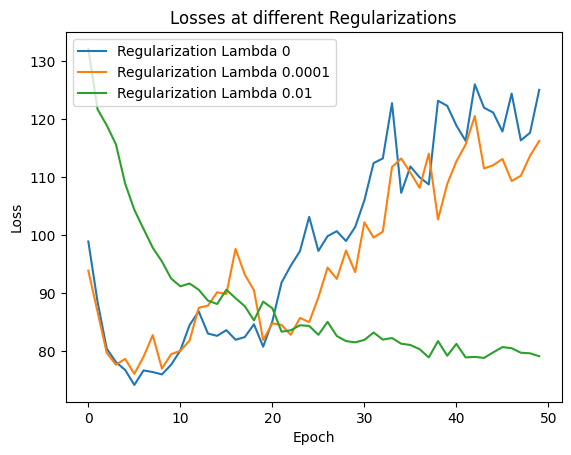

In [ ]:
for lambda_l2, losses in val_losses.items():
    plt.plot(losses, label=f'Regularization Lambda {lambda_l2}')
plt.title('Losses at different Regularizations')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

* Around epoch 5, unregularized model hit least loss and then increased loss, suggesting overfitting after that.
* Regularization parameter $\lambda = 10^{-4}$ also overfit, but its final loss is less. 
* But regulariztion with $\lambda = 10^{-2}$ is much better as it didn't overfit at all: it started off with a higher validation loss but reduced more gradually to a much lower final loss.

## Solution 6

In [ ]:
# TODO

## Solution 8

In [ ]:
# TODO

## Solution 9

In [ ]:
# TODO

## Solution 12

In [ ]:
# TODO

## Solution 14

In [ ]:
# TODO

## Solution 15

In [ ]:
# TODO